# 为深度学习学 Python：动手练习

这份 Notebook 对应博客中的 Python 入门教程，按变量、容器、函数、类、张量、训练循环的顺序组织。所有数据由代码生成，不需要下载数据集。先预测输出，再执行；可以修改数字和参数，观察变化。

## 使用方法

在自己的虚拟环境中安装 NumPy、Matplotlib、PyTorch、JupyterLab 和 ipywidgets。PyTorch 请按[官方安装页](https://pytorch.org/get-started/locally/)选择系统和 CPU 平台；其他包可用 `python -m pip install numpy matplotlib jupyterlab ipywidgets` 安装。

运行 `python -m jupyterlab`，打开本文件，选择对应的 Python 内核。`Shift + Enter` 执行当前单元格。首次学习请从上到下执行；修改过变量后，可重启内核并运行全部单元格。

本文验证环境是 Python 3.14.3、PyTorch 2.11.0、NumPy 2.4.4、Matplotlib 3.10.9。交互控件需要内核持续运行。下方保留了普通函数调用的输出，静态查看也能读到结果。

In [1]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
torch.set_num_threads(1)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("NumPy:", np.__version__)
print("设备：CPU")

Python: 3.14.3
PyTorch: 2.11.0
NumPy: 2.4.4
设备：CPU


## 2.1 赋值与计算

In [2]:
learning_rate = 0.01
epochs = 20
print(learning_rate)
print(epochs)

0.01
20


`=` 表示赋值：先计算右边，再让左边的名称指向这个结果。`learning_rate` 和 `epochs` 是变量名。变量不需要提前声明类型，这里的值分别是浮点数和整数。

学习率用于控制模型每次更新参数的幅度；epoch 表示完整遍历训练数据的一轮。暂时只需要把它们看作两个有具体用途的数值。

变量名区分大小写，`epochs` 与 `Epochs` 是两个名称。常用的小写加下划线写法，如 `batch_size`，能让多个单词更容易辨认。

In [3]:
step = 0
step = step + 1
print(step)  # 1

1


第二行先算出 `0 + 1`，再把 `step` 绑定到 `1`。它也可以写成 `step += 1`。数学等式不会这样使用等号，读程序时要留意这个差别。

`#` 后面是注释，解释器会忽略。注释适合说明用途、单位或容易误解的地方。

常见运算符如下：

| 写法 | 含义 | 结果 |
| --- | --- | --- |
| `7 + 2` | 加法 | `9` |
| `7 - 2` | 减法 | `5` |
| `7 * 2` | 乘法 | `14` |
| `7 / 2` | 除法 | `3.5` |
| `7 // 2` | 向下取整的除法 | `3` |
| `7 % 2` | 取余数 | `1` |
| `2 ** 3` | 乘方 | `8` |

`//` 的结果向负无穷取整，所以 `-7 // 2` 是 `-4`。`**` 才是乘方；`^` 在 Python 中是按位异或，不能拿来写平方。

## 2.2 数字、字符串、布尔值和 None

In [4]:
sample_count = 100          # int，整数
accuracy = 0.875            # float，浮点数
experiment = "first_run"   # str，字符串
shuffle = True             # bool，布尔值
checkpoint = None          # 暂时没有检查点路径

print(type(sample_count))
print(type(accuracy))

<class 'int'>
<class 'float'>


输出：

```text
<class 'int'>
<class 'float'>
```

`type(...)` 可以查看一个值的类型。遇到不理解的运算结果时，先打印类型往往比猜测有效。

字符串用英文单引号或双引号包围，两者都可以。编辑器里输入代码时应使用英文标点，中文引号 `“ ”` 无法代替字符串的引号。

In [5]:
print("3" + "2")  # 32，拼接字符串
print(3 + 2)      # 5，数字相加
print(int("3") + 2)  # 5，把字符串转成整数

32
5
5


`True` 和 `False` 首字母大写。比较运算会得到布尔值：

In [6]:
print(3 == 3)   # True，判断相等
print(3 != 3)   # False，判断不等
print(0.8 >= 0.9)  # False

True
False
False


`None` 用来表示缺失或尚未提供的值。例如，没有指定模型文件时，可以把路径设为 `None`。检查它通常写 `checkpoint is None`。`0`、空字符串和 `None` 各有不同含义，是否视为缺失应由程序约定。

浮点数只能有限精度地表示数值：

In [7]:
print(0.1 + 0.2)  # 0.30000000000000004

0.30000000000000004


因此，计算结果是否接近某个小数，通常需要允许一个误差范围。后面比较张量时，会使用相应的近似比较方法。

## 2.3 输出可读的训练记录

In [8]:
epoch = 3
loss = 0.12678
accuracy = 0.875
print(f"第 {epoch} 轮，loss={loss:.3f}，准确率={accuracy:.1%}")

第 3 轮，loss=0.127，准确率=87.5%


输出：

```text
第 3 轮，loss=0.127，准确率=87.5%
```

字符串前面的 `f` 允许在花括号中插入表达式。`:.3f` 保留三位小数，`:.1%` 按百分数显示并保留一位小数。它们只影响显示格式，变量里的值没有改变。

loss 称为损失，用一个数衡量预测与目标的偏差。如何计算它将在第 9 章介绍，目前只是练习输出一个小数。

## 2.4 缩进也是语法

In [9]:
accuracy = 0.875
if accuracy >= 0.8:
    print("达到本次练习的目标")
    print("可以保存结果")
print("程序结束")

达到本次练习的目标
可以保存结果
程序结束


`if` 后面是条件，冒号后面换行。缩进的两行属于条件成立时执行的代码块，最后一行回到最左边，无论条件是否成立都会执行。

本文统一用四个空格缩进。可以让编辑器把 Tab 自动转换为空格，避免混用。复杂代码可以先通过缩进找出它的层次，再读每一行的内容。

本章练习：共有 80 个样本，预测正确 62 个。用变量保存这两个数，计算准确率，并用 f-string 输出一位小数的百分比。答案应是 `77.5%`。注意参与计算的数值应为整数，别加上字符串引号。

## 3.1 列表与索引

In [10]:
point = [0.2, 0.7]
print(point[0])   # 0.2
print(point[1])   # 0.7
print(point[-1])  # 0.7
print(len(point)) # 2

0.2
0.7
0.7
2


`[]` 创建列表，列表中的位置从 `0` 开始编号。负数索引从末尾向前数，`-1` 是最后一个元素。`len` 返回元素数量。

长度为 2 的列表没有 `point[2]`；访问它会出现 `IndexError`。这个错误通常说明索引超出了范围，应检查列表长度和索引的来源。

列表能嵌套：

In [11]:
points = [[0.2, 0.7], [-0.8, -0.3], [0.6, -0.1]]
labels = [1, 0, 1]
print(points[1])     # [-0.8, -0.3]
print(points[1][0])  # -0.8

[-0.8, -0.3]
-0.8


`points[1][0]` 分两步读取：先取第二个点，再取该点的第一个坐标。这里约定 `points[i]` 与 `labels[i]` 对应同一个样本。后续调整顺序时，必须保持这种对应关系。

列表可以修改，也可以添加元素：

In [12]:
losses = [0.9, 0.6]
losses.append(0.4)
losses[0] = 1.0
print(losses)  # [1.0, 0.6, 0.4]

[1.0, 0.6, 0.4]


`losses.append(...)` 是调用列表的一个方法。点号把对象和它提供的属性或方法连起来；带括号表示调用。在这里，`append` 把值加到列表末尾。

`append` 修改原列表，返回值是 `None`。不要写 `losses = losses.append(0.4)`，否则 `losses` 会被重新赋值为 `None`。

## 3.2 切片：一次取出一段

In [13]:
values = [10, 20, 30, 40, 50]
print(values[1:4])   # [20, 30, 40]
print(values[:3])    # [10, 20, 30]
print(values[3:])    # [40, 50]
print(values[::2])   # [10, 30, 50]
print(values[::-1])  # [50, 40, 30, 20, 10]

[20, 30, 40]
[10, 20, 30]
[40, 50]
[10, 30, 50]
[50, 40, 30, 20, 10]


切片写作 `起点:终点:步长`，包含起点，不包含终点。省略起点或终点时，正向切片默认从开头开始或取到末尾。步长为负数时向前取，`[::-1]` 常用于倒序。

比如 `points[:2]` 取前两个点。这种写法之后会出现在训练集划分、批次抽取和张量索引中。

## 3.3 元组与解包

In [14]:
shape = (32, 2)
batch_size, feature_count = shape
print(batch_size)     # 32
print(feature_count)  # 2

32
2


元组通常用圆括号表示，创建后不能替换其中的元素，适合表达固定的一组值。这里的 `shape` 表示一批有 32 个样本，每个样本有两个特征，也就是两个坐标。

`batch_size, feature_count = shape` 叫解包：把右侧的两个元素依次赋给左侧的两个变量。普通解包时数量要一致。列表也支持同样的操作。

单元素元组要写成 `(2,)`，逗号不能省略；`(2)` 只是加了括号的整数。

元组的不可变性指它所保存的各项引用不能被替换。如果其中有一个列表，列表自身仍可能被修改。因此，用元组包装数据并不等于把内部所有内容都冻结。

## 3.4 字典与集合

列表按位置取值，字典按键取值：

In [15]:
config = {
    "learning_rate": 0.01,
    "batch_size": 32,
    "epochs": 20,
}
print(config["batch_size"])       # 32
config["epochs"] = 30
print(config.get("device", "cpu"))  # cpu
print("epochs" in config)         # True

32
cpu
True


冒号左侧是键，右侧是值。配置项用字典保存，比记住某个数在列表的第几个位置更方便。`config["device"]` 在键不存在时会报 `KeyError`；`get` 可以指定默认值。

默认值适合可选配置。如果某项数据必须存在，直接索引能及时暴露缺失问题。什么都用默认值补上，可能让程序带着错误的配置继续运行。

集合可以去重，也适合检查成员是否存在：

In [16]:
labels = [1, 0, 1, 1, 0]
classes = set(labels)
print(len(classes))  # 2
print(1 in classes)  # True

2
True


集合不提供稳定的排列顺序。需要按编号显示类别时，可以用 `sorted(classes)` 得到排序后的列表。空集合用 `set()` 创建，`{}` 创建的是空字典。

## 3.5 赋值不会自动复制数据

这点值得单独运行一次：

In [17]:
a = [1, 2, 3]
b = a
b[0] = 99
print(a)  # [99, 2, 3]

[99, 2, 3]


`a` 和 `b` 指向同一个列表，所以通过 `b` 修改，也会在读取 `a` 时看到变化。如果需要一个独立的外层列表，可以这样写：

In [18]:
a = [1, 2, 3]
b = a.copy()
b[0] = 99
print(a)  # [1, 2, 3]

[1, 2, 3]


但 `copy()` 是浅复制。嵌套列表里的内层对象仍然共享：

In [19]:
a = [[1, 2], [3, 4]]
b = a.copy()
b[0][0] = 99
print(a)  # [[99, 2], [3, 4]]

[[99, 2], [3, 4]]


需要递归复制这种嵌套结构时，可以使用标准库的 `copy.deepcopy`。到张量部分，还会遇到共享存储的问题；那时应区分赋值、切片、复制以及梯度关系，不能把列表的经验直接套到所有对象上。

本章练习：建立三个二维点和对应标签，取出第二个点，将两个坐标解包到 `x1`、`x2`，再取前两个点形成一个小批次。最后预测上面浅复制示例的输出，再运行检查。能解释为什么外层复制后内层仍会变化，比记住 `copy` 的名称更有用。

## 4.1 条件判断

In [20]:
point = [0.2, 0.7]
score = point[0] + point[1]
if score > 0:
    prediction = 1
else:
    prediction = 0
print(prediction)  # 1

1


条件成立时执行 `if` 下的代码块，否则执行 `else` 下的代码块。需要依次检查多个条件时，可以加入 `elif`：

In [21]:
score = 0.03
if score > 0.1:
    print("明显位于正侧")
elif score < -0.1:
    print("明显位于负侧")
else:
    print("靠近分界线")

靠近分界线


条件从上到下检查，执行第一个成立的分支后，就跳过其余分支。`else` 负责前面的条件都不成立时的情况。

多个条件可以用 `and`、`or`、`not` 组合，例如 `score > 0 and score < 1`，也可以写成 `0 < score < 1`。这几种写法适用于普通数值。以后对整批张量逐元素比较，要使用张量支持的逻辑运算，第 8 章会给出例子。

## 4.2 for 与 range

In [22]:
points = [[0.2, 0.7], [-0.8, -0.3], [0.6, -0.1]]
for point in points:
    score = point[0] + point[1]
    print(score > 0)

True
False
True


输出依次是 `True`、`False`、`True`。每轮循环，`point` 都绑定到列表中的下一个元素。循环体执行完后，才继续取下一个点。

只需要重复指定次数时，可以使用 `range`：

In [23]:
for epoch in range(3):
    print(f"开始第 {epoch + 1} 轮")

开始第 1 轮
开始第 2 轮
开始第 3 轮


`range(3)` 依次提供 `0`、`1`、`2`，不包含 `3`。显示时加一，方便按日常习惯编号。`range(1, 4)` 则依次提供 `1`、`2`、`3`。

`range` 不会预先建立一个装满整数的列表。需要查看它的所有值时，可以写 `list(range(3))`。平时直接在循环中使用即可。

## 4.3 enumerate 与 zip

既要样本，又要编号，可以用 `enumerate`：

In [24]:
points = [[0.2, 0.7], [-0.8, -0.3], [0.6, -0.1]]
for index, point in enumerate(points):
    print(index, point)

0 [0.2, 0.7]
1 [-0.8, -0.3]
2 [0.6, -0.1]


`enumerate` 每次提供一对值：编号和当前元素。`index, point` 把这对值解包到两个变量。它默认从 0 编号，也可以用 `enumerate(points, start=1)`。

如果要同时读取样本和标签：

In [25]:
points = [[0.2, 0.7], [-0.8, -0.3], [0.6, -0.1]]
labels = [1, 0, 1]
correct = 0
for point, target in zip(points, labels):
    prediction = int(point[0] + point[1] > 0)
    if prediction == target:
        correct += 1
print(correct / len(labels))  # 1.0

1.0


`zip` 从两个容器中各取一个元素，组成一对。`int(True)` 得到 `1`，`int(False)` 得到 `0`，因此这里把条件判断的结果转成了类别编号。

`zip` 默认在最短的输入耗尽时结束。样本和标签数量不一致时，它可能悄悄少处理一些数据。Python 3.10 及以上可以写 `zip(points, labels, strict=True)`，让长度不一致直接报错。

现在试着拆开这一行：

In [26]:
for index, (point, target) in enumerate(zip(points, labels)):
    print(index, point, target)

0 [0.2, 0.7] 1
1 [-0.8, -0.3] 0
2 [0.6, -0.1] 1


它接续上一个例子的变量。先由 `zip` 产生 `(point, target)`，再由 `enumerate` 加上编号，形成 `(index, (point, target))`。左侧按同样的结构解包。后面看到 `for batch_idx, (inputs, targets) in enumerate(loader)` 时，语法结构完全相同。

## 4.4 推导式、break 与 continue

如果循环只是逐项计算结果并存入一个新列表，可以写成列表推导式：

In [27]:
values = [1, 2, 3, 4]
squares = [value ** 2 for value in values]
positive = [value for value in [-2, 0, 3, 5] if value > 0]
print(squares)   # [1, 4, 9, 16]
print(positive)  # [3, 5]

[1, 4, 9, 16]
[3, 5]


阅读顺序可以先看 `for`，确定数据来自哪里，再看前面的表达式，确定每项算什么。带有 `if` 时，先筛选，再计算。表达式太长或包含多层判断时，展开为普通循环会更容易维护。

`continue` 跳过本轮剩余代码，`break` 结束最近的一层循环：

In [28]:
values = [-1, 2, 4, 8]
for value in values:
    if value < 0:
        continue
    if value > 5:
        break
    print(value)

2
4


这里只输出 `2` 和 `4`。`while` 则在条件成立期间反复执行，例如 `while step < 10:`。使用它时要确保循环体有机会改变条件，否则可能一直运行。遍历现成数据或固定轮数时，`for` 通常更直接。

本章练习：把第三个标签故意改成 `0`，重新计算准确率。应得到约 `0.667`。再用 `enumerate` 输出预测错误的样本编号。参考思路是在判断 `prediction != target` 时打印编号，别在循环结束之后才检查最后一个样本。

## 5.1 定义、调用与返回值

In [29]:
def predict_point(point):
    score = point[0] + point[1]
    return int(score > 0)

prediction = predict_point([0.2, 0.7])
print(prediction)  # 1

1


`def` 开始定义函数，`point` 是参数。定义时，函数体尚未运行；执行 `predict_point(...)` 才会把传入的列表交给它，并执行缩进部分。`return` 把结果交回调用处，同时结束本次调用。

`print` 只负责显示内容。如果把函数里的 `return` 换成 `print`，调用时虽然能看到类别，但 `prediction` 会得到 `None`。函数没有执行带值的 `return` 时，默认返回 `None`。

一个函数可以返回多个相关结果：

In [30]:
def describe(values):
    return min(values), max(values)

low, high = describe([0.2, 0.7, -0.3])
print(low, high)  # -0.3 0.7

-0.3 0.7


这里返回的是一个元组，调用处用解包接收。`min` 与 `max` 是 Python 自带的函数，分别求最小值和最大值。

## 5.2 位置参数、关键字参数和默认值

In [31]:
def predict_point(point, threshold=0.0):
    return int(point[0] + point[1] > threshold)

print(predict_point([0.2, 0.7]))                 # 1
print(predict_point([0.2, 0.7], 1.0))            # 0
print(predict_point([0.2, 0.7], threshold=1.0))  # 0

1
0
0


第一种调用采用默认阈值，第二种按位置传参，第三种按参数名传参。参数较多时，写出名称能减少顺序混淆。以后见到 `nn.Linear(in_features=2, out_features=16)`，可以按这个方式阅读。

默认参数有一个常见陷阱：列表、字典等可变对象作为默认值时，会在多次调用间共享。不要用 `def record(value, history=[]):` 来表示每次都新建一个列表。可以写成：

In [32]:
def record(value, history=None):
    if history is None:
        history = []
    history.append(value)
    return history

print(record(0.8))  # [0.8]
print(record(0.6))  # [0.6]

[0.8]
[0.6]


传入已有列表时，函数会修改那个列表。这与第 3 章的引用关系一致：把对象传给函数，不会自动复制它。

## 5.3 看懂 *args 和 **kwargs

星号在函数定义和函数调用中有两种相关的用途：收集与展开。

定义时，`*args` 收集额外的位置参数，形成元组：

In [33]:
def total(*args):
    return sum(args)

print(total(1, 2, 3))  # 6

6


`**kwargs` 收集额外的关键字参数，形成字典：

In [34]:
def show_options(**kwargs):
    print(kwargs)

show_options(batch_size=32, shuffle=True)

{'batch_size': 32, 'shuffle': True}


输出：

```text
{'batch_size': 32, 'shuffle': True}
```

`args` 和 `kwargs` 是约定俗成的名称，语法作用来自星号。多数日常函数写清楚具体参数就足够了；这里主要是为阅读框架代码做准备。

调用时，星号把已有容器展开为参数：

In [35]:
def add(a, b):
    return a + b

values = [2, 3]
options = {"a": 2, "b": 3}
print(add(*values))     # 等价于 add(2, 3)
print(add(**options))   # 等价于 add(a=2, b=3)

5
5


展开字典时，键必须符合函数可接收的参数名；同一个参数也不能既按位置传入，又通过字典重复传入。

## 5.4 作用域与类型提示

函数内部创建的变量通常只在该次调用内部使用：

In [36]:
def scale(value, factor):
    result = value * factor
    return result

answer = scale(3, 2)
print(answer)  # 6

6


外部可以读取 `answer`，却不能直接读取函数里的局部变量 `result`。需要输出什么，就通过 `return` 返回；需要输入什么，尽量通过参数传入。这样单独阅读函数时，比较容易看清依赖。

你还可能遇到：

In [37]:
def scale(value: float, factor: float = 2.0) -> float:
    return value * factor

参数后的 `: float` 和箭头后的 `float` 是类型提示。它们帮助读者、编辑器和检查工具理解预期类型，Python 默认不会据此自动转换数值或强制拒绝其他类型。`scale("a", 2)` 仍会得到字符串 `"aa"`。

`lambda x: x * 2` 是一种简短的匿名函数写法，适合很短的表达式。需要多行步骤、注释或重复使用时，用 `def` 会更清楚。有关参数的完整规则，可以按需查阅 [Python 函数定义文档](https://docs.python.org/zh-cn/3/tutorial/controlflow.html#defining-functions)。

本章练习：定义 `accuracy(predictions, targets)`，返回两个类别列表的匹配比例。先检查长度是否相等，并规定空列表怎样处理。可以暂时为无效输入返回 `None`；第 7 章学会异常后，再改为明确报错。用 `[1, 0, 1]` 和 `[1, 0, 0]` 检查，结果应约为 `0.667`。

## 6.1 从一个保存样本的类开始

In [38]:
class PointDataset:
    def __init__(self, points, labels):
        self.points = points
        self.labels = labels

    def __len__(self):
        return len(self.points)

    def __getitem__(self, index):
        return self.points[index], self.labels[index]

samples = PointDataset([[0.2, 0.7], [-0.8, -0.3]], [1, 0])
print(len(samples))  # 2
print(samples[0])    # ([0.2, 0.7], 1)

2
([0.2, 0.7], 1)


`class PointDataset:` 定义一种对象。`PointDataset(...)` 创建一个实例；初始化过程中，`__init__` 接收传入的数据，把它们保存到实例属性上。

`self` 表示当前实例。`self.points = points` 左边是保存到实例上的属性，右边是本次调用传入的参数。构造函数返回后，局部参数的名称结束使用，但通过 `samples.points` 仍能读取保存的样本。

方法是定义在类中的函数。调用实例方法时，Python 会自动把实例传给第一个参数，所以创建对象或调用普通实例方法时，一般不手动填写 `self`。这个名字本身是惯例，保持惯例最容易让别人读懂。

`__len__` 和 `__getitem__` 是特殊方法，分别让对象支持 `len(samples)` 与 `samples[index]`。双下划线也是方法名的一部分，需要准确拼写。仅有这个例子还不能处理任意输入，比如样本与标签长度不一致时会出问题；正式实现中应验证这类约束。

## 6.3 继承与 super

继承允许一个类沿用另一个类的行为，再添加或修改部分方法：

In [39]:
class BaseExperiment:
    def __init__(self, name):
        self.name = name

    def describe(self):
        return f"实验：{self.name}"

class ClassificationExperiment(BaseExperiment):
    def __init__(self, name, class_count):
        super().__init__(name)
        self.class_count = class_count

experiment = ClassificationExperiment("二维点分类", 2)
print(experiment.describe())  # 实验：二维点分类

实验：二维点分类


括号里的 `BaseExperiment` 是父类。`super().__init__(name)` 在这里调用父类的初始化方法，建立 `name` 属性，随后子类增加自己的 `class_count`。

阅读 `class Classifier(nn.Module)` 时，可以沿用这个思路：`Classifier` 继承 PyTorch 的 `nn.Module`，后者提供参数管理、设备迁移等功能；我们负责定义网络层和前向计算。第 9 章会给出完整实现。现在先认识结构，不必提前记住网络接口。

`super()` 在复杂的多重继承中遵循方法解析顺序，不能一概理解成固定指向某个父类。本教程只使用上面这样的单继承。

## 6.4 可迭代对象、迭代器与生成器

列表能够出现在 `for` 后面，因为它支持迭代。可以显式取得一个迭代器，再逐次取值：

In [40]:
values = [10, 20]
iterator = iter(values)
print(next(iterator))  # 10
print(next(iterator))  # 20

10
20


再调用一次 `next` 会产生 `StopIteration`，表示没有更多元素。`for` 会处理正常的迭代结束，因此不需要在循环里手动捕获它。迭代器被取完后，通常需要从原来的可迭代对象重新创建一个。

生成器是一种方便编写迭代器的方式：

In [41]:
def batches(values, batch_size):
    for start in range(0, len(values), batch_size):
        yield values[start:start + batch_size]

for batch in batches([10, 20, 30, 40, 50], 2):
    print(batch)

[10, 20]
[30, 40]
[50]


输出：

```text
[10, 20]
[30, 40]
[50]
```

`yield` 交出当前批次，并暂停函数；下次请求元素时从暂停处继续。调用含有 `yield` 的函数会创建生成器，实际取值时才执行函数体。例子约定 `batch_size` 是正整数。

一个 batch 就是一起处理的一小批样本。这里最后一批只有一个元素，可见批次大小不一定整齐。后面计算整轮平均损失时，需要按实际样本数加权。

生成器按需生成批次，但这个例子的 `values` 已经完整保存在内存中，不能因此认为原始数据也没有占用内存。PyTorch 的 `DataLoader` 会提供更完整的分批与加载功能。

本章练习：给 `PointDataset` 增加第三条数据，检查 `len(samples)` 与 `samples[2]` 的结果。再把生成器的批次大小改为 `3`，预测输出。有关对象和继承的更多规则，见 [Python 类与迭代器文档](https://docs.python.org/zh-cn/3/tutorial/classes.html)。

## 7.2 路径与 JSON 配置

In [42]:
from pathlib import Path
import json

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)
config = {"learning_rate": 0.01, "batch_size": 32}

with (output_dir / "config.json").open("w", encoding="utf-8") as file:
    json.dump(config, file, ensure_ascii=False, indent=2)

with (output_dir / "config.json").open("r", encoding="utf-8") as file:
    loaded_config = json.load(file)

print(loaded_config["batch_size"])  # 32

32


`Path` 表示路径，`/` 在这里用于拼接目录和文件名。`mkdir` 创建目录；`parents=True` 允许同时创建缺少的父目录，`exist_ok=True` 允许目录已经存在。

`"w"` 是写入模式，会覆盖同名文件原有内容；`"r"` 是读取模式。`with` 负责在代码块结束时关闭文件，即使中途出现异常，也会执行相应的清理操作。后面会见到 `with torch.no_grad():`，形式相似，但它管理的是梯度记录状态。

JSON 适合保存数字、字符串、列表、字典等基础配置。`dump` 写入文件，`load` 从文件读取。张量无法直接交给普通 `json.dump` 保存，模型参数会使用 PyTorch 的保存接口。

相对路径从当前工作目录解析，不一定从脚本所在目录解析。遇到找不到文件时，先打印 `Path.cwd()`。需要相对于脚本定位文件时，可以在 `.py` 文件中使用 `Path(__file__).resolve().parent`；Notebook 通常没有 `__file__`。

## 7.3 读懂 traceback

假设代码写成：

In [43]:
values = [10, 20]
# print(values[2])  # 去掉注释会触发 IndexError

报错会包含文件名、行号和调用过程，最后一行给出异常类型与简要原因。先看最后一行，再回到属于自己代码的出错位置，检查参与运算的值。

| 异常 | 常见检查方向 |
| --- | --- |
| `NameError` | 名称是否拼错，定义是否已经执行 |
| `TypeError` | 对象类型、参数数量、是否误把属性当函数调用 |
| `IndexError` | 索引是否越界 |
| `KeyError` | 字典是否包含这个键 |
| `ModuleNotFoundError` | 包是否装在当前解释器环境中 |
| `RuntimeError` | 阅读具体信息；张量形状或设备不匹配常由它报告 |

调试时先缩小范围。例如在报错前打印 `type(value)` 和 `value`；到了张量部分，再打印 `shape`、`dtype` 和 `device`。观察到的实际值，比变量名称更可靠。

## 7.4 主动拒绝无效输入

第五章的准确率函数可以完善为：

In [44]:
def accuracy(predictions, targets):
    if len(predictions) != len(targets):
        raise ValueError("预测数量与标签数量不一致")
    if len(targets) == 0:
        raise ValueError("无法计算空数据集的准确率")
    correct = sum(p == t for p, t in zip(predictions, targets))
    return correct / len(targets)

print(accuracy([1, 0, 1], [1, 0, 0]))  # 0.6666666666666666

0.6666666666666666


`raise` 主动抛出异常。这里传给 `sum` 的是生成器表达式：逐对比较，`True` 在求和时贡献 1，`False` 贡献 0。

如果调用处有明确的处理方式，可以捕获预期异常：

In [45]:
try:
    value = int("not-a-number")
except ValueError:
    print("输入无法转换为整数")

输入无法转换为整数


不要把整段训练包进一个宽泛的 `try`，然后用 `except: pass` 忽略所有错误。程序继续运行，却没有完成原本的工作，会使问题更难追踪。

本章练习：把准确率函数放进 `helpers.py`，从 `main.py` 导入，并分别测试正常输入、长度不同和空列表。确认后两种情况能指出具体问题，再继续学习张量。

## 8.1 先认识 NumPy 数组

In [46]:
import numpy as np

array = np.array([[1, 2], [3, 4]], dtype=np.float32)
print(array * 2)
print(array.shape)
print(array.mean(axis=0))

[[2. 4.]
 [6. 8.]]
(2, 2)
[2. 3.]


输出：

```text
[[2. 4.]
 [6. 8.]]
(2, 2)
[2. 3.]
```

NumPy 数组的 `* 2` 对每个元素相乘。`shape` 表示每个维度的长度，这里有两行、两列。`dtype` 指定元素类型，`float32` 是 32 位浮点数。

`mean(axis=0)` 沿第 0 个轴求平均，把行这一维归约掉，留下每列的平均值。因此结果是 `[(1+3)/2, (2+4)/2]`。`mean(axis=1)` 则得到每一行的平均值 `[1.5, 3.5]`。

NumPy 常用于数据处理。PyTorch 的张量提供类似的数值操作，并支持自动求导以及在适当硬件上进行加速运算。下面直接转入张量，NumPy 的更多接口可以以后按需补充。

## 8.2 shape、dtype、device

In [47]:
import torch

x = torch.tensor([[1, 2], [3, 4], [5, 6]], dtype=torch.float32)
print(x.shape)   # torch.Size([3, 2])
print(x.dtype)   # torch.float32
print(x.device)  # cpu
print(x.ndim)    # 2

torch.Size([3, 2])
torch.float32
cpu
2


这个张量表示三个样本，每个样本有两个特征。`shape` 回答数据怎样排列，`dtype` 回答元素用什么类型保存，`device` 回答数据放在哪里。多数入门张量错误都可以先从这三项排查。

维度编号从 0 开始。这里 `x.shape[0]` 是样本数，`x.shape[1]` 是特征数。`ndim` 是轴的数量，不等于样本数，也不等于元素总数。

| 形状 | 本文约定的含义 |
| --- | --- |
| `[]` | 标量，例如一个平均损失 |
| `[2]` | 一个点的两个坐标 |
| `[32, 2]` | 一批 32 个点 |
| `[32]` | 这批点对应的 32 个类别编号 |
| `[32, 2]` | 也可能是每个点对两个类别的预测分数 |

最后两种二维数据可以有相同形状，却有不同含义。形状只能说明尺寸，具体语义要结合变量用途判断。

浮点输入与整数标签常这样创建：

In [48]:
features = torch.tensor([[0.2, 0.7], [-0.8, -0.3]], dtype=torch.float32)
labels = torch.tensor([1, 0], dtype=torch.long)

本教程使用类别编号形式的交叉熵损失，所以标签采用 `torch.long`。其他任务可能需要浮点目标，不能把所有标签都机械地转成整数。

## 8.3 按行、按列取值

In [49]:
import torch

x = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
print(x[0])       # tensor([1., 2.])
print(x[:, 0])    # tensor([1., 3., 5.])
print(x[:2])      # 前两个样本，形状 [2, 2]
print(x[:, 0:1])  # 第一列，保留形状 [3, 1]

tensor([1., 2.])
tensor([1., 3., 5.])
tensor([[1., 2.],
        [3., 4.]])
tensor([[1.],
        [3.],
        [5.]])


多维索引用逗号分隔每个维度。`x[:, 0]` 中，冒号取所有行，`0` 取第一列。整数索引会移除被选中的那一维；切片 `0:1` 会保留它，所以 `[3]` 与 `[3, 1]` 有区别。

布尔张量也能筛选：

In [50]:
mask = x[:, 0] > 2
print(mask)     # tensor([False, True, True])
print(x[mask])  # 取出后两行

tensor([False,  True,  True])
tensor([[3., 4.],
        [5., 6.]])


这里接续上面的 `x`。如果要组合逐元素条件，可写 `(x[:, 0] > 2) & (x[:, 1] < 6)`，各条件用括号包好。对包含多个元素的张量直接写 `if x > 0:`，程序无法知道你要求所有元素成立还是任意一个成立。需要明确写出 `(x > 0).all()` 或 `(x > 0).any()`，或用掩码逐项处理。

## 8.4 逐元素运算、矩阵乘法与广播

In [51]:
import torch

x = torch.tensor([[1., 2.], [3., 4.]])
print(x * x)
print(x @ x)

tensor([[ 1.,  4.],
        [ 9., 16.]])
tensor([[ 7., 10.],
        [15., 22.]])


输出：

```text
tensor([[ 1.,  4.],
        [ 9., 16.]])
tensor([[ 7., 10.],
        [15., 22.]])
```

`*` 对对应位置相乘，`@` 做矩阵乘法。矩阵乘法把左侧的一行与右侧的一列对应相乘再求和，例如结果左上角是 `1*1 + 2*3 = 7`。

对于二维矩阵，`[B, D] @ [D, H]` 的结果是 `[B, H]`。中间的 `D` 必须一致。可以把它理解为一批 `B` 个样本，每个有 `D` 个特征，经过权重矩阵后变成 `H` 个数。

广播允许一些形状不同的张量做逐元素运算：

In [52]:
import torch

x = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
bias = torch.tensor([10., 20.])
print(x + bias)

tensor([[11., 22.],
        [13., 24.],
        [15., 26.]])


结果是 `[[11, 22], [13, 24], [15, 26]]` 对应的浮点张量。长度为 2 的 `bias` 被用于每一行。

判断能否广播时，从最右边的维度向左比较：长度相等，或者其中一个为 1，即可兼容；缺少的前置维度按 1 处理。例如 `[3, 2]` 与 `[2]` 能得到 `[3, 2]`，但 `[3, 2]` 与 `[3]` 不能直接相加。这个规则与 [NumPy 广播规则](https://numpy.org/doc/stable/user/basics.broadcasting.html)一致。

尤其要留意 `[B, 1]` 与 `[B]`。二者相减可能得到 `[B, B]`，这时每个值都与另一组的所有值进行了比较。如果你原本只想逐样本相减，程序虽然能运行，计算含义却变了。排查损失异常时，应同时核对结果形状。

## 8.5 改变形状与求平均

In [53]:
import torch

x = torch.arange(6, dtype=torch.float32).reshape(3, 2)
print(x)
print(x.mean(dim=0))               # tensor([2., 3.])
print(x.mean(dim=1))               # tensor([0.5000, 2.5000, 4.5000])
print(x.mean(dim=1, keepdim=True).shape)  # torch.Size([3, 1])
print(x.reshape(-1).shape)         # torch.Size([6])

tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])
tensor([2., 3.])
tensor([0.5000, 2.5000, 4.5000])
torch.Size([3, 1])
torch.Size([6])


`arange(6)` 生成从 0 到 5 的数，`reshape(3, 2)` 把六个元素排成三行两列。改变形状前后，元素总数必须一致；`-1` 让程序推算这一维的长度，一次最多使用一个。

PyTorch 通常用 `dim` 指定归约的轴，NumPy 的类似参数叫 `axis`。`keepdim=True` 保留被归约的维度，长度变为 1。例如每行减去自己的均值时，可以写 `x - x.mean(dim=1, keepdim=True)`，这样 `[3, 1]` 会沿列广播。

`unsqueeze` 增加一个长度为 1 的维度：一个形状为 `[2]` 的点，经 `point.unsqueeze(0)` 后变成 `[1, 2]`，就可以作为只有一条样本的批次输入模型。`squeeze(dim=1)` 则移除指定的长度为 1 的维度。直接调用不带维度的 `squeeze()` 会移除所有长度为 1 的维度，批次恰好只有一个样本时容易误删批次维。

`reshape` 按元素顺序重新安排形状，转置则交换轴。对于上面的 `x`，`x.reshape(2, 3)` 与 `x.transpose(0, 1)` 虽然形状相同，元素排列却不同。交换图像的通道轴时，应该学习 `permute` 或 `transpose`，不要仅靠 `reshape` 凑尺寸。

## 8.6 张量也可能共享数据

In [54]:
import torch

x = torch.tensor([1., 2., 3.])
y = x[:2]
y[0] = 9
print(x)  # tensor([9., 2., 3.])

tensor([9., 2., 3.])


张量的基本切片通常产生视图，和原张量共享底层存储。需要独立副本时用 `clone()`。`reshape` 可能返回视图，也可能复制，取决于布局，因此不要依靠它来保证数据独立。

从 NumPy 转换时也要留意：`torch.from_numpy(array)` 通常共享数组存储；修改一方可能影响另一方。`torch.tensor(array)` 则会复制数据。更多示例见 [PyTorch 张量教程](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)。

后面自动求导会用到 `detach()`：它得到一个脱离当前求导关系的张量，但仍共享存储。如果既要脱离求导关系，又要独立数据，应使用 `detach().clone()`。

## 8.7 自动求导先看一个数

In [55]:
import torch

w = torch.tensor(2.0, requires_grad=True)
loss = (w - 5) ** 2
loss.backward()
print(loss.item())  # 9.0
print(w.grad)      # tensor(-6.)

9.0
tensor(-6.)


`requires_grad=True` 表示要跟踪涉及 `w` 的计算，用于之后求导。`backward()` 根据已经发生的计算求出梯度，保存到 `w.grad`。

这里的函数是 `(w-5)²`，导数为 `2(w-5)`，在 `w=2` 时等于 `-6`。如果沿梯度的反方向小幅移动：`w ← w - 0.1 × (-6)`，新的 `w` 是 `2.6`，更接近使损失最小的 `5`。神经网络训练中，参数很多，优化器会替我们执行相应更新。

`backward()` 只计算梯度，不会自行更新 `w`。梯度默认会累积，多次训练时需要适时清除；第 9 章的 `optimizer.zero_grad()` 就负责这件事。

`.item()` 把单元素张量转为 Python 数值，适合打印和记录。要参与求导的损失应保留张量形式；先转成普通数字，就不能再对这个数字调用 `backward()`。

记录 loss 时可以保存 `loss.item()`，避免把带有求导关系的张量长期装进历史列表。求导流程详见 [PyTorch 自动求导教程](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)。

## 8.8 设备迁移

本文的示例使用 CPU。以后需要加速时，可以在设备可用的前提下选择 CUDA 或 macOS 的 MPS。迁移张量通常写 `x = x.to(device)`，模型也需要迁移；参与同一次运算的数据和参数应放在兼容的设备上。

`.to(...)` 可能返回新张量，因此不要调用后就丢弃返回值。要把用于求导或位于加速设备上的张量交给常见的 NumPy 绘图流程，可以使用 `tensor.detach().cpu().numpy()`。先脱离求导关系，再移到 CPU，最后转换为数组。

本章练习：创建形状为 `[4, 2]` 的浮点张量，完成四件事：取第一列、计算每行均值、保留维度后进行逐行去均值、给一个点增加批次维。每一步先写下预计形状，再打印核对。最后解释为什么 `[4, 1] - [4]` 会得到 `[4, 4]`。

## 交互实验一：切片与形状

先运行默认例子。随后改变行数或列数，观察 `x[:, 0]` 和 `x[:, 0:1]` 的差别。每行均值使用 `keepdim=True`，保留长度为 1 的列维。

In [56]:
def inspect_shape(rows=3, columns=2):
    x = torch.arange(rows * columns, dtype=torch.float32).reshape(rows, columns)
    print("原张量", tuple(x.shape))
    print(x)
    print("第一列 x[:, 0]：", tuple(x[:, 0].shape), x[:, 0])
    print("保留列维 x[:, 0:1]：", tuple(x[:, 0:1].shape))
    print(x[:, 0:1])
    means = x.mean(dim=1, keepdim=True)
    print("每行均值：", tuple(means.shape))
    print(means)
    print("逐行去均值：")
    print(x - means)

inspect_shape(3, 2)

原张量 (3, 2)
tensor([[0., 1.],
        [2., 3.],
        [4., 5.]])
第一列 x[:, 0]： (3,) tensor([0., 2., 4.])
保留列维 x[:, 0:1]： (3, 1)
tensor([[0.],
        [2.],
        [4.]])
每行均值： (3, 1)
tensor([[0.5000],
        [2.5000],
        [4.5000]])
逐行去均值：
tensor([[-0.5000,  0.5000],
        [-0.5000,  0.5000],
        [-0.5000,  0.5000]])


In [57]:
import ipywidgets as widgets

widgets.interact(
    inspect_shape,
    rows=widgets.IntSlider(value=3, min=1, max=6, description="行数", continuous_update=False),
    columns=widgets.IntSlider(value=2, min=1, max=5, description="列数", continuous_update=False),
);

interactive(children=(IntSlider(value=3, continuous_update=False, description='行数', max=6, min=1), IntSlider(v…

## 9. 二维点分类

下面重建完整实验，不依赖外部脚本。600 个标准正态随机点，标签规则为 `x1 + x2 > 0`。480 个训练样本、120 个测试样本，固定随机种子 42。测试集只在训练完成后评估。

先定义数据集与模型，再定义数据生成、训练与评估函数。可以对照正文逐个阅读。

In [58]:
from pathlib import Path
import json
from torch import nn
from torch.utils.data import Dataset, DataLoader

### PointDataset

In [59]:
class PointDataset(Dataset):
    def __init__(self, points, labels):
        if len(points) != len(labels):
            raise ValueError("样本数量与标签数量不一致")
        self.points = points
        self.labels = labels

    def __len__(self):
        return len(self.points)

    def __getitem__(self, index):
        return self.points[index], self.labels[index]

### Classifier

In [60]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 2),
        )

    def forward(self, x):
        return self.layers(x)

### make_data

In [61]:
def make_data(seed=42):
    generator = torch.Generator().manual_seed(seed)
    points = torch.randn(600, 2, generator=generator)
    labels = (points[:, 0] + points[:, 1] > 0).long()
    order = torch.randperm(len(points), generator=generator)
    train_ids, test_ids = order[:480], order[480:]
    return points[train_ids], labels[train_ids], points[test_ids], labels[test_ids]

### train_epoch

In [62]:
def train_epoch(model, loader, loss_fn, optimizer):
    model.train()
    loss_sum = 0.0
    sample_count = 0
    for inputs, targets in loader:
        optimizer.zero_grad()
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(inputs)
        sample_count += len(inputs)
    return loss_sum / sample_count

### evaluate

In [63]:
def evaluate(model, points, labels, loss_fn):
    model.eval()
    with torch.no_grad():
        logits = model(points)
        loss = loss_fn(logits, labels).item()
        predictions = logits.argmax(dim=1)
        accuracy = (predictions == labels).float().mean().item()
    return loss, accuracy

### run_experiment

In [64]:
def run_experiment(learning_rate=0.03, epochs=40, seed=42, verbose=True):
    torch.manual_seed(seed)
    train_x, train_y, test_x, test_y = make_data(seed)
    dataset = PointDataset(train_x, train_y)
    generator = torch.Generator().manual_seed(seed + 1)
    loader = DataLoader(dataset, batch_size=32, shuffle=True,
                        num_workers=0, generator=generator)
    model = Classifier()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    history = []
    for epoch in range(epochs):
        loss = train_epoch(model, loader, loss_fn, optimizer)
        history.append(loss)
        if verbose and (epoch == 0 or (epoch + 1) % 10 == 0):
            print(f"epoch={epoch + 1:02d}, train_loss={loss:.4f}")
    test_loss, test_accuracy = evaluate(model, test_x, test_y, loss_fn)
    if verbose:
        print(f"test_loss={test_loss:.4f}, test_accuracy={test_accuracy:.1%}")
    return model, history, test_x, test_y, test_accuracy

### 运行默认实验

In [65]:
model, history, test_x, test_y, test_accuracy = run_experiment()

epoch=01, train_loss=0.5930
epoch=10, train_loss=0.2015
epoch=20, train_loss=0.1321
epoch=30, train_loss=0.1045
epoch=40, train_loss=0.0891
test_loss=0.0991, test_accuracy=100.0%


### 画出样本、预测与损失

两类使用不同颜色和标记形状。散点图中的虚线是生成标签时的已知分界线，不是从模型提取的决策边界。损失曲线记录训练期间各批次按样本数加权的平均损失。

In [66]:
def draw_results(model, history, test_x, test_y):
    plt.rcParams.update({"font.size": 12, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.dpi": 130})
    colors = ["#2864a0", "#bf701e"]
    markers = ["o", "^"]
    figures = []
    model.eval()
    with torch.no_grad():
        predictions = model(test_x).argmax(dim=1)

    for title, labels in [("Test samples: true labels", test_y),
                          ("Test samples: model predictions", predictions)]:
        fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
        for category in [0, 1]:
            points = test_x[labels == category]
            ax.scatter(points[:, 0], points[:, 1], s=32, alpha=0.8,
                       color=colors[category], marker=markers[category],
                       label=f"Class {category}")
        ax.plot([-3.5, 3.5], [3.5, -3.5], color="#555555",
                linestyle="--", linewidth=1.3, label="True boundary")
        ax.set(xlabel="x1", ylabel="x2", title=title,
               xlim=(-3.5, 3.5), ylim=(-3.5, 3.5))
        ax.set_aspect("equal")
        ax.legend(fontsize=10, loc="upper right")
        figures.append(fig)

    fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
    ax.plot(range(1, len(history) + 1), history, color=colors[0], linewidth=1.8)
    ax.set(xlabel="Epoch", ylabel="Mean training loss",
           title="Training loss: 480 synthetic samples", ylim=(0, None),
           xlim=(1, len(history)), xticks=[1, 10, 20, 30, 40])
    ax.grid(axis="y", alpha=0.2)
    figures.append(fig)
    return figures

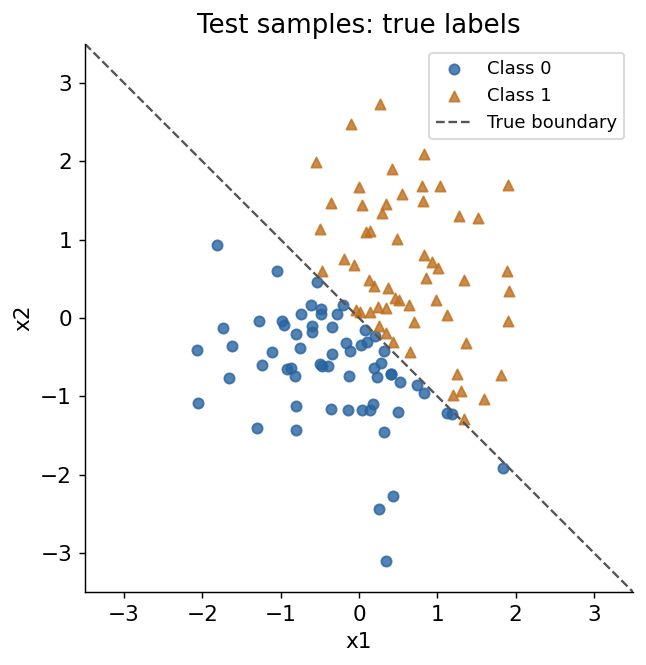

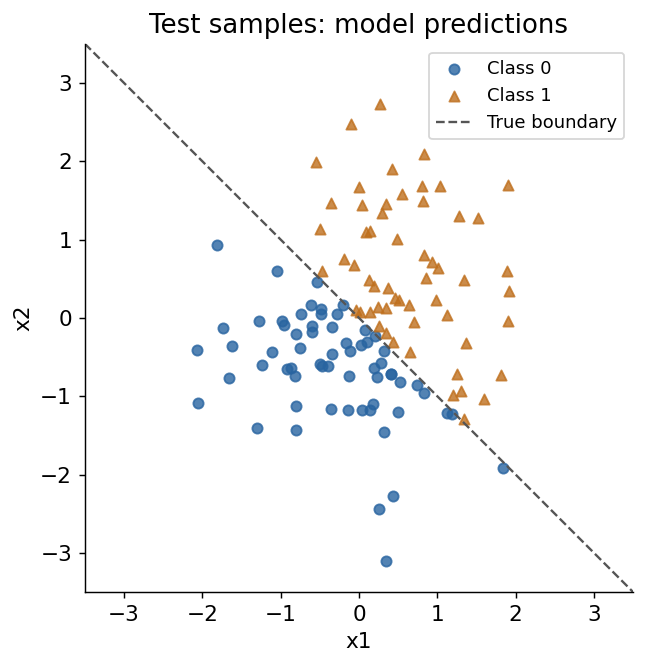

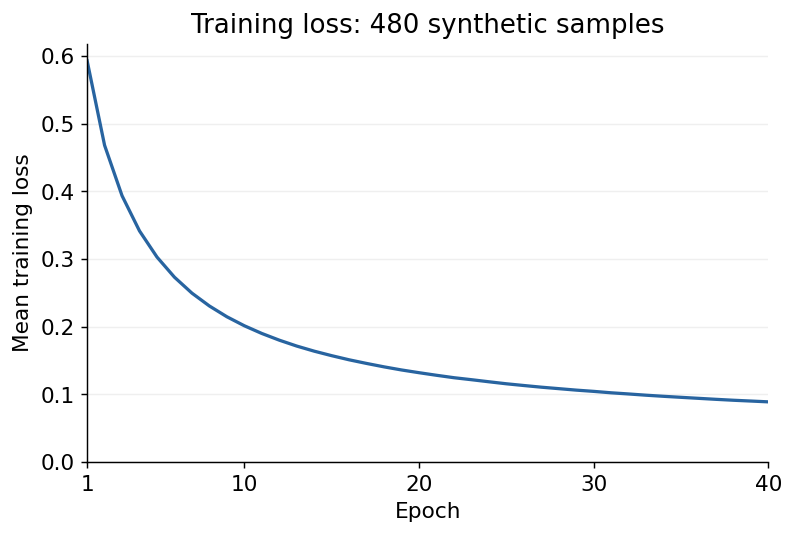

In [67]:
figures = draw_results(model, history, test_x, test_y)
for figure in figures:
    display(figure)
    plt.close(figure)

这次默认实验的测试准确率为 100%，只说明这次留出的 120 个点全部分类正确。这个任务有简单的线性边界，结果不能推及真实图像或文本任务。运行环境变化时，数值可能略有差异。

### 保存、重新加载并验证

In [68]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
torch.save(model.state_dict(), output_dir / "point-model.pt")
restored = Classifier()
restored.load_state_dict(torch.load(output_dir / "point-model.pt", map_location="cpu", weights_only=True))
restored.eval()
model.eval()
with torch.no_grad():
    torch.testing.assert_close(model(test_x), restored(test_x))
    new_points = torch.tensor([[0.2, 0.7], [-0.8, -0.3]], dtype=torch.float32)
    print("新点类别：", restored(new_points).argmax(dim=1).tolist())
print("保存前后的预测分数一致")

新点类别： [1, 0]
保存前后的预测分数一致


## 交互实验二：改变学习率

固定数据、初始化种子与批次顺序，只调整学习率和轮数。这里仅绘制训练损失，不用测试准确率选择参数。建议依次比较 0.003、0.03、0.3；记录相同轮数时的损失，以及是否出现明显波动。点击按钮后才重新训练。

若控件未显示，修改下方 `compare_learning_rate(0.03, 40)` 的参数并重新执行。

第一轮：0.5930，最后一轮：0.0891


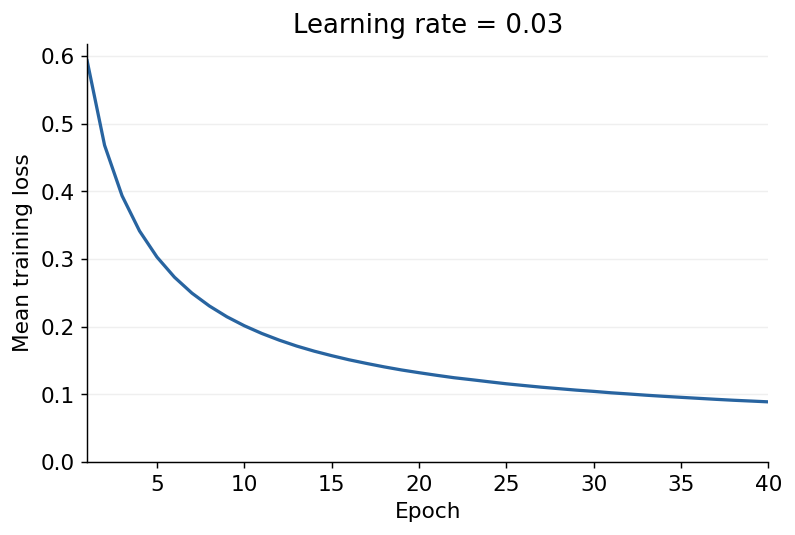

In [69]:
def compare_learning_rate(learning_rate=0.03, epochs=40):
    torch.manual_seed(42)
    train_x, train_y, _, _ = make_data(42)
    loader = DataLoader(PointDataset(train_x, train_y), batch_size=32, shuffle=True,
                        num_workers=0, generator=torch.Generator().manual_seed(43))
    candidate = Classifier()
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(candidate.parameters(), lr=learning_rate)
    losses = [train_epoch(candidate, loader, loss_fn, optimizer) for _ in range(epochs)]
    fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
    ax.plot(range(1, epochs + 1), losses, color="#2864a0", linewidth=1.8)
    ax.set(xlabel="Epoch", ylabel="Mean training loss",
           title=f"Learning rate = {learning_rate:g}", ylim=(0, None), xlim=(1, epochs))
    ax.grid(axis="y", alpha=0.2)
    print(f"第一轮：{losses[0]:.4f}，最后一轮：{losses[-1]:.4f}")
    display(fig)
    plt.close(fig)
    return losses

baseline_losses = compare_learning_rate(0.03, 40)

In [70]:
learning_rate_demo = widgets.interactive(
    compare_learning_rate,
    {"manual": True, "manual_name": "运行训练"},
    learning_rate=widgets.SelectionSlider(
        options=[0.003, 0.01, 0.03, 0.1, 0.3], value=0.03, description="学习率"),
    epochs=widgets.IntSlider(value=40, min=10, max=80, step=10, description="轮数"),
)
display(learning_rate_demo)

interactive(children=(SelectionSlider(description='学习率', index=2, options=(0.003, 0.01, 0.03, 0.1, 0.3), value…

## 检查与下一步

下方核对默认运行的损失、保存前后的预测和张量形状。修改模型或训练参数后，检查不通过时先看具体原因，避免直接删掉检查。

下一步可以把隐藏层宽度从 16 改为 8，或用单个 `nn.Linear(2, 2)` 完成分类。需要调参时另划验证集，测试集留到最后。

参考：[Python 官方教程](https://docs.python.org/zh-cn/3/tutorial/index.html)、[NumPy 广播](https://numpy.org/doc/stable/user/basics.broadcasting.html)、[PyTorch 入门](https://docs.pytorch.org/tutorials/beginner/basics/intro.html)。

In [71]:
assert len(history) == 40
assert history[-1] < history[0]
assert test_x.shape == (120, 2)
assert test_y.dtype == torch.long
assert np.allclose(history, baseline_losses)
print("默认实验的训练记录与形状检查通过")

默认实验的训练记录与形状检查通过
